In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue',  'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

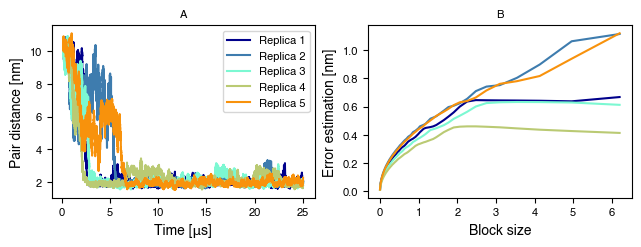

In [3]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/MARTINI/convergence/pairdist_'
pairs = list(combinations(range(32), 2))

color_pick = 0
for nr in range(1, 6):
    counter = 0
    for pair in pairs:
        t, dist = np.genfromtxt((work_dir + str(nr) + '/Chain' + str(pair[0]) + '/' + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                                usecols=(0, 1), skip_header=24, unpack=True)
        if counter == 0:
            dist_ave = dist
        else:
            dist_ave += dist
        counter += 1
    ax[0].plot((t*(10**-6)), (dist_ave/counter), color=color_list[color_pick])

    with open(work_dir + str(nr) + '/dist_ave.xvg', 'w') as save:
        for (p1, p2) in zip(t, (dist_ave/counter)):
            save.write(str(p1) + ' ' + str(p2) + '\n')

    t, ee = np.genfromtxt((work_dir + str(nr) + '/errest.xvg'), usecols=(0, 1), skip_header=26, unpack=True)
    ax[1].plot((t*(10**-6)), ee, color=color_list[color_pick])
    color_pick += 24

ax[0].tick_params(labelsize=font)
ax[1].tick_params(labelsize=font)
ax[0].set_ylabel('Pair distance [nm]', fontsize=font_label)
ax[0].set_xlabel('Time [μs]', fontsize=font_label)
ax[1].set_ylabel('Error estimation [nm]', fontsize=font_label)
ax[1].set_xlabel('Block size', fontsize=font_label)
ax[0].set_title('A', fontsize=font)
ax[1].set_title('B', fontsize=font)
ax[0].legend(['Replica 1', 'Replica 2', 'Replica 3', 'Replica 4', 'Replica 5'], fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/CG_pairdist_convergence.pdf', dpi=1000)

#ax[0].axhline(1.9)
#ax[0].set_ylim(1.5, 2.5)

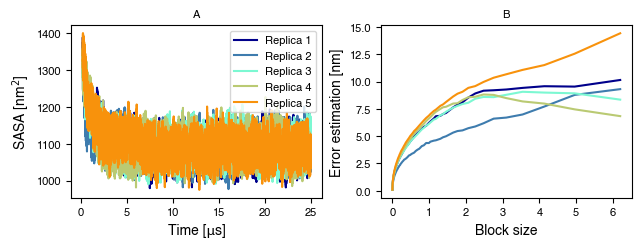

In [4]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/MARTINI/convergence/'

color_pick = 0
for nr in range(1, 6):
    t, sasa = np.genfromtxt((work_dir + 'sasa_' + str(nr) + '.xvg'), usecols=(0, 1), skip_header=24, unpack=True)
    ax[0].plot((t*(10**-6)), sasa, color=color_list[color_pick])
    t, ee = np.genfromtxt((work_dir + 'sasa_ee_' + str(nr) + '.xvg'), usecols=(0, 1), skip_header=26, unpack=True)
    ax[1].plot((t*(10**-6)), ee, color=color_list[color_pick])
    color_pick += 24

ax[0].tick_params(labelsize=font)
ax[1].tick_params(labelsize=font)
ax[0].set_ylabel('SASA [nm$^{2}$]', fontsize=font_label)
ax[0].set_xlabel('Time [μs]', fontsize=font_label)
ax[1].set_ylabel('Error estimation [nm]', fontsize=font_label)
ax[1].set_xlabel('Block size', fontsize=font_label)
ax[0].set_title('A', fontsize=font)
ax[1].set_title('B', fontsize=font)
ax[0].legend(['Replica 1', 'Replica 2', 'Replica 3', 'Replica 4', 'Replica 5'], fontsize=font, loc='upper right')
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/CG_sasa_convergence.pdf', dpi=1000)